In [1]:
import json
import pandas as pd

valid_items = []
inside_items = False
brace_count = 0
current_obj_lines = []

with open("acndata_sessions (7).json", "r", encoding="utf-8") as f:
    for line in f:
        line_strip = line.strip()
        
        # Detect start of "_items" array
        if not inside_items and line_strip.startswith('"\\_items"') or line_strip.startswith('_items'):
            inside_items = True
            continue
        
        # Detect end of "_items" array
        if inside_items and line_strip.startswith(']'):
            break
        
        # Skip empty lines
        if not line_strip:
            continue
        
        # Accumulate JSON objects line by line
        if line_strip.startswith('{'):
            brace_count = 1
            current_obj_lines = [line_strip]
        elif brace_count > 0:
            brace_count += line_strip.count('{')
            brace_count -= line_strip.count('}')
            current_obj_lines.append(line_strip)
        
        # If braces are balanced, try to parse
        if brace_count == 0 and current_obj_lines:
            obj_text = "\n".join(current_obj_lines)
            try:
                obj = json.loads(obj_text)
                valid_items.append(obj)
            except json.JSONDecodeError:
                pass  # skip truncated object
            current_obj_lines = []

# Convert to DataFrame
df = pd.json_normalize(valid_items)
print(df.head())
print(f"Recovered {len(df)} valid items.")

   WhPerMile  kWhRequested  milesRequested  minutesAvailable  \
0        400          75.2             188               514   
1        350           7.0              20               471   
2        250          52.5             210               373   
3        350           7.0              20               405   
4        400          12.0              30               386   

                      modifiedAt  paymentRequired  \
0  Tue, 11 Feb 2020 04:45:09 GMT             True   
1  Tue, 11 Feb 2020 20:25:34 GMT             True   
2  Tue, 11 Feb 2020 23:50:34 GMT             True   
3  Wed, 12 Feb 2020 18:05:16 GMT             True   
4  Wed, 12 Feb 2020 18:40:51 GMT             True   

              requestedDeparture  userID  
0  Tue, 11 Feb 2020 05:28:47 GMT    6140  
1  Tue, 11 Feb 2020 23:37:05 GMT    6062  
2  Wed, 12 Feb 2020 00:39:55 GMT    6171  
3  Wed, 12 Feb 2020 22:06:31 GMT    6062  
4  Thu, 13 Feb 2020 01:02:30 GMT    4400  
Recovered 585 valid items.


In [2]:
import json

valid_items = []

with open("acndata_sessions (7).json", "r", encoding="utf-8") as f:
    text = f.read()

# Try to split the "_items" array manually
items_start = text.find('" _items": [')
items_end = text.rfind(']')  # may need to adjust

items_text = text[items_start + len('" _items": ['):items_end]

# Split by closing brace, crude but works for many JSONs
for entry in items_text.split('},'):
    if not entry.endswith('}'):
        entry += '}'
    try:
        valid_items.append(json.loads(entry))
    except:
        continue

print(f"Recovered {len(valid_items)} items")

Recovered 1658 items


In [3]:
import json

with open("acndata_sessions_clean.json", "w", encoding="utf-8") as f:
    json.dump({"_items": valid_items}, f, ensure_ascii=False, indent=2)

In [4]:
import pandas as pd

df = pd.json_normalize(valid_items)
print(df.info())
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1658 entries, 0 to 1657
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   _id                 1632 non-null   object 
 1   clusterID           1632 non-null   object 
 2   connectionTime      1632 non-null   object 
 3   disconnectTime      1632 non-null   object 
 4   doneChargingTime    1578 non-null   object 
 5   kWhDelivered        1632 non-null   float64
 6   sessionID           1632 non-null   object 
 7   siteID              1632 non-null   object 
 8   spaceID             1632 non-null   object 
 9   stationID           1632 non-null   object 
 10  timezone            1632 non-null   object 
 11  userID              561 non-null    object 
 12  userInputs          535 non-null    object 
 13  WhPerMile           26 non-null     float64
 14  kWhRequested        26 non-null     float64
 15  milesRequested      26 non-null     float64
 16  minute

In [5]:
df_small = df[["connectionTime", "doneChargingTime", "kWhDelivered"]]

print(df_small.head())

                  connectionTime               doneChargingTime  kWhDelivered
0  Mon, 25 Mar 2019 17:19:27 GMT  Mon, 25 Mar 2019 18:00:49 GMT         3.658
1  Mon, 25 Mar 2019 21:27:32 GMT  Tue, 26 Mar 2019 02:10:40 GMT        28.330
2  Tue, 26 Mar 2019 18:33:56 GMT  Tue, 26 Mar 2019 22:30:58 GMT        12.978
3  Wed, 27 Mar 2019 18:28:01 GMT  Wed, 27 Mar 2019 21:44:03 GMT        10.688
4  Thu, 28 Mar 2019 00:32:33 GMT  Thu, 28 Mar 2019 03:23:22 GMT        17.591


In [6]:
df_small["connectionTime"] = pd.to_datetime(df_small["connectionTime"], errors="coerce")
df_small["doneChargingTime"] = pd.to_datetime(df_small["doneChargingTime"], errors="coerce")

C:\Users\betsie_0410\AppData\Local\Temp\ipykernel_16480\2151034609.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_small["connectionTime"] = pd.to_datetime(df_small["connectionTime"], errors="coerce")
C:\Users\betsie_0410\AppData\Local\Temp\ipykernel_16480\2151034609.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_small["doneChargingTime"] = pd.to_datetime(df_small["doneChargingTime"], errors="coerce")


In [7]:
df_small = df_small.dropna(subset=["connectionTime", "doneChargingTime"])

In [8]:
df_small["charging_hours"] = (
    df_small["doneChargingTime"] - df_small["connectionTime"]
).dt.total_seconds() / 3600

In [9]:
print(df_small.head())

       connectionTime    doneChargingTime  kWhDelivered  charging_hours
0 2019-03-25 17:19:27 2019-03-25 18:00:49         3.658        0.689444
1 2019-03-25 21:27:32 2019-03-26 02:10:40        28.330        4.718889
2 2019-03-26 18:33:56 2019-03-26 22:30:58        12.978        3.950556
3 2019-03-27 18:28:01 2019-03-27 21:44:03        10.688        3.267222
4 2019-03-28 00:32:33 2019-03-28 03:23:22        17.591        2.846944


In [10]:
df_small["avg_power_kW"] = df_small["kWhDelivered"] / df_small["charging_hours"]

In [11]:
print(df_small.head())

       connectionTime    doneChargingTime  kWhDelivered  charging_hours  \
0 2019-03-25 17:19:27 2019-03-25 18:00:49         3.658        0.689444   
1 2019-03-25 21:27:32 2019-03-26 02:10:40        28.330        4.718889   
2 2019-03-26 18:33:56 2019-03-26 22:30:58        12.978        3.950556   
3 2019-03-27 18:28:01 2019-03-27 21:44:03        10.688        3.267222   
4 2019-03-28 00:32:33 2019-03-28 03:23:22        17.591        2.846944   

   avg_power_kW  
0      5.305721  
1      6.003532  
2      3.285108  
3      3.271280  
4      6.178905  


In [12]:
print(len(df_small))

1578


In [13]:
# Set connectionTime as index
df_small = df_small.set_index("connectionTime")

# Resample hourly: compute average power per hour
hourly_power = df_small["avg_power_kW"].resample("H").mean()

C:\Users\betsie_0410\AppData\Local\Temp\ipykernel_16480\1363119764.py:5: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hourly_power = df_small["avg_power_kW"].resample("H").mean()


In [14]:
daily_power = df_small["avg_power_kW"].resample("D").mean()

Locator attempting to generate 3096 ticks ([431540.0, ..., 453205.0]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 3096 ticks ([431540.0, ..., 453205.0]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 3096 ticks ([431540.0, ..., 453205.0]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 3096 ticks ([431540.0, ..., 453205.0]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 3096 ticks ([431540.0, ..., 453205.0]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 3096 ticks ([431540.0, ..., 453205.0]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 3096 ticks ([431540.0, ..., 453205.0]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 3096 ticks ([431540.0, ..., 453205.0]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 3096 ticks ([431540.0, ..., 453205.0]), which exceeds Locator.MAXTICKS (1000).
Locator at

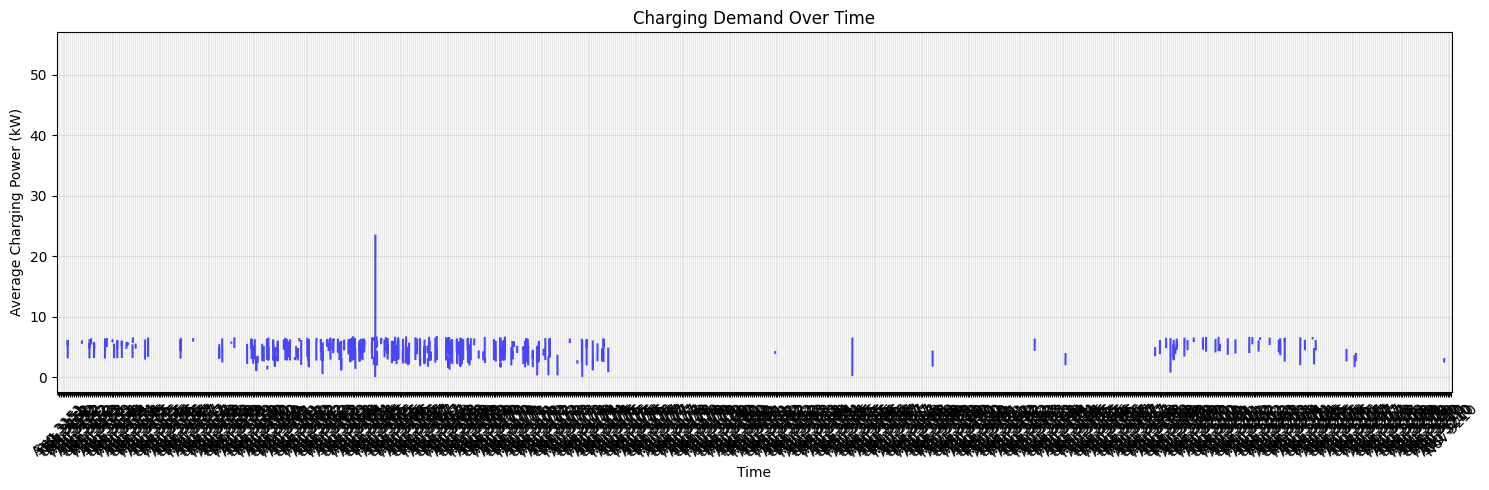

In [15]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(15,5))

# Plot hourly or daily average power
hourly_power.plot(ax=ax, color="blue", alpha=0.7)

# Set major ticks to months
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

# Optional: minor ticks by week
ax.xaxis.set_minor_locator(mdates.WeekdayLocator(byweekday=mdates.MO))

ax.set_ylabel("Average Charging Power (kW)")
ax.set_xlabel("Time")
ax.set_title("Charging Demand Over Time")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [16]:
hourly_power.fillna(0, inplace=True)

<Axes: xlabel='connectionTime'>

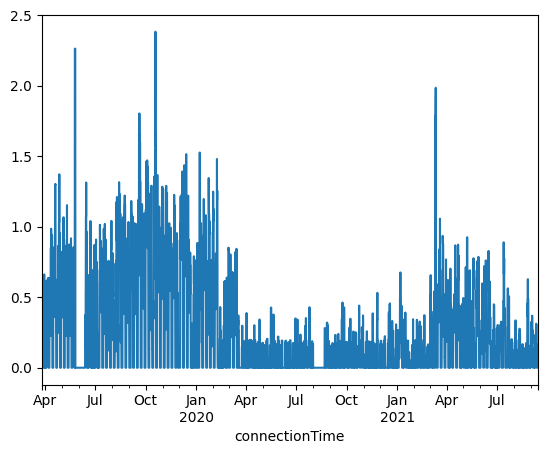

In [17]:
hourly_power.rolling(24).mean().plot()

In [18]:
df_small["avg_power_kW"] = df_small["kWhDelivered"] / df_small["charging_hours"]

In [19]:
df_small[df_small["avg_power_kW"] < 0]

,doneChargingTime,kWhDelivered,charging_hours,avg_power_kW
connectionTime,,,,


In [20]:
df_small = df_small[df_small["avg_power_kW"] > 0]

In [21]:
hourly_energy = {}

for idx, row in df_small.iterrows():

    start = idx   # connectionTime is the index
    end = row["doneChargingTime"]
    energy = row["kWhDelivered"]

    duration = (end - start).total_seconds()

    current = start

    while current < end:

        next_hour = (current + pd.Timedelta(hours=1)).floor("H")

        segment_end = min(end, next_hour)

        segment_seconds = (segment_end - current).total_seconds()

        energy_share = energy * (segment_seconds / duration)

        hour = current.floor("H")

        hourly_energy[hour] = hourly_energy.get(hour, 0) + energy_share

        current = segment_end


hourly_energy = pd.Series(hourly_energy).sort_index()

# hourly power (kWh per hour = kW)
hourly_power = hourly_energy

C:\Users\betsie_0410\AppData\Local\Temp\ipykernel_16480\3507591723.py:15: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  next_hour = (current + pd.Timedelta(hours=1)).floor("H")
C:\Users\betsie_0410\AppData\Local\Temp\ipykernel_16480\3507591723.py:23: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hour = current.floor("H")


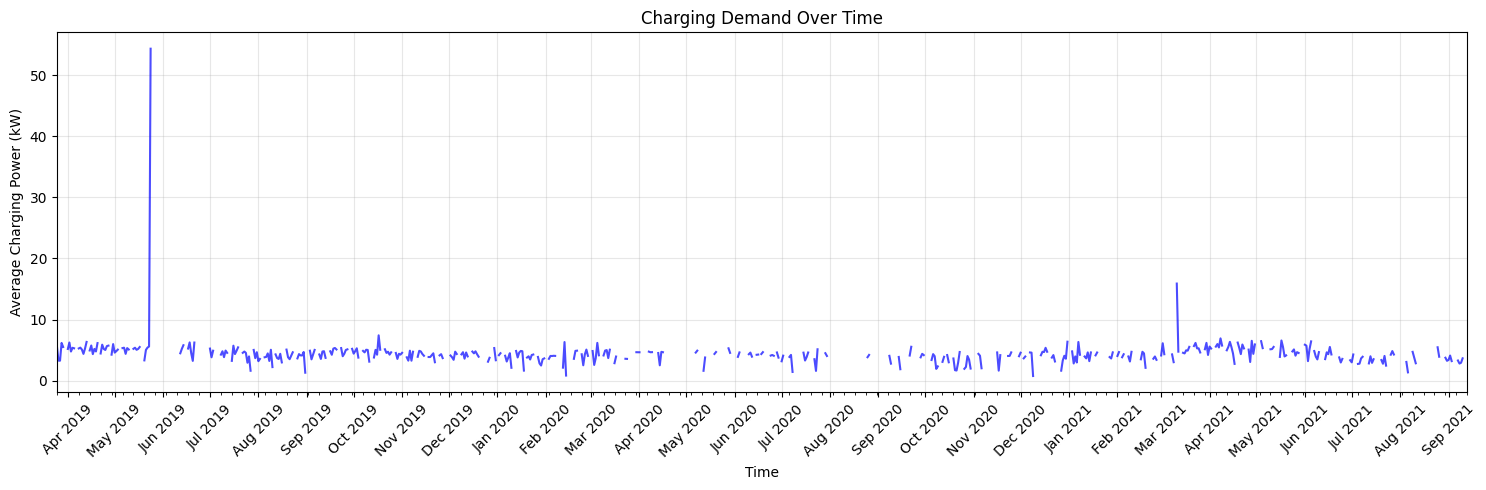

In [22]:
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(15,5))

# Resample to daily averages
daily_power = df_small["avg_power_kW"].resample("D").mean()
daily_power.plot(ax=ax, color="blue", alpha=0.7)

# Major ticks: first day of each month
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

# Optional: minor ticks by week
ax.xaxis.set_minor_locator(mdates.WeekdayLocator(byweekday=mdates.MO))

ax.set_ylabel("Average Charging Power (kW)")
ax.set_xlabel("Time")
ax.set_title("Charging Demand Over Time")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

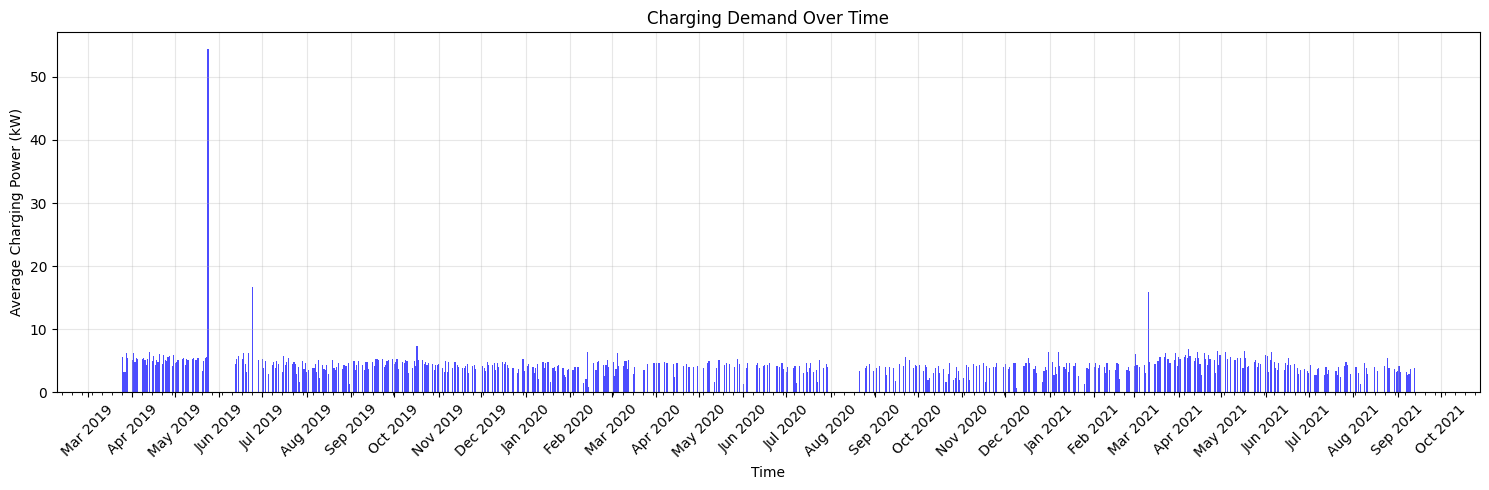

In [23]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(15,5))

# Resample to daily averages
daily_power = df_small["avg_power_kW"].resample("D").mean()

# Use bars instead of line
ax.bar(daily_power.index, daily_power.values, color="blue", alpha=0.7, width=0.8)

# Major ticks: first day of each month
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

# Optional: minor ticks by week
ax.xaxis.set_minor_locator(mdates.WeekdayLocator(byweekday=mdates.MO))

ax.set_ylabel("Average Charging Power (kW)")
ax.set_xlabel("Time")
ax.set_title("Charging Demand Over Time")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

C:\Users\betsie_0410\AppData\Local\Temp\ipykernel_16480\699986044.py:10: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hourly_data = df_small["avg_power_kW"].resample("H").mean().reindex(
C:\Users\betsie_0410\AppData\Local\Temp\ipykernel_16480\699986044.py:11: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  pd.date_range(df_small.index.min().normalize(),


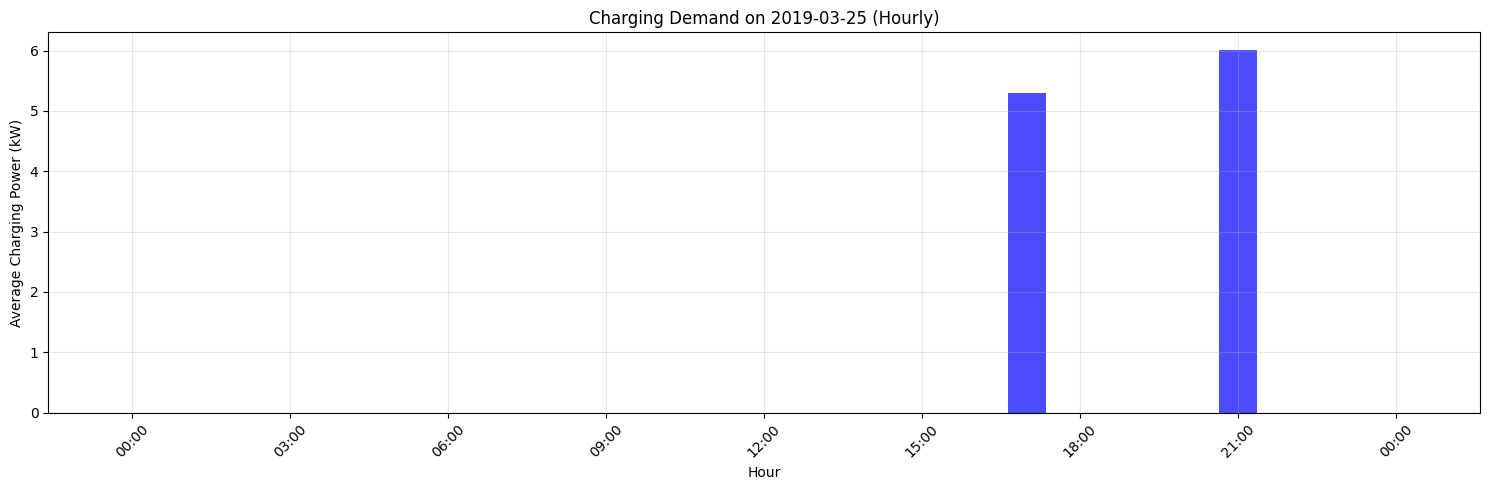

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Make sure index is datetime
df_small.index = pd.to_datetime(df_small.index)

# Resample hourly to ensure uniform time steps
#hourly_data = df_small["avg_power_kW"].resample("H").mean()
hourly_data = df_small["avg_power_kW"].resample("H").mean().reindex(
    pd.date_range(df_small.index.min().normalize(),
                  df_small.index.max().normalize() + pd.Timedelta(days=1),
                  freq='H')
)

# Group by day and find days that have 24 hourly entries
complete_days = hourly_data.groupby(hourly_data.index.date).filter(lambda x: len(x) == 24)

# Get the first complete day
if not complete_days.empty:
    first_day_date = complete_days.index[0].normalize()  # midnight of first full day
    hourly_power = hourly_data[first_day_date:first_day_date + pd.Timedelta(days=1)]
    hourly_power = hourly_power.fillna(0)
#    hourly_power = hourly_data.loc[first_day_date:first_day_date + pd.Timedelta(days=1)].reindex(
#        pd.date_range(first_day_date, periods=24, freq='H')
#   )
else:
    raise ValueError("No day with complete 24 hours of data found.")

# Plot
fig, ax = plt.subplots(figsize=(15,5))
ax.bar(hourly_power.index, hourly_power.values, color="blue", alpha=0.7, width=0.03)

# Format x-axis to show hours
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax.set_ylabel("Average Charging Power (kW)")
ax.set_xlabel("Hour")
ax.set_title(f"Charging Demand on {first_day_date.date()} (Hourly)")

plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

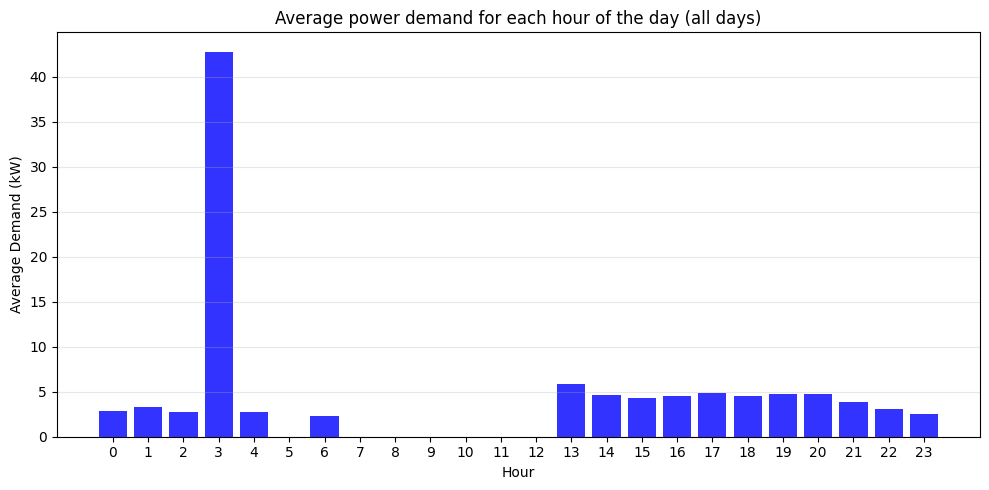

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

# Compute hourly mean
hourly_avg = df_small["avg_power_kW"].groupby(df_small.index.hour).mean()

# Ensure all 24 hours are present
hourly_avg = hourly_avg.reindex(range(24), fill_value=0)  # or use fill_value=np.nan

# Plot
fig, ax = plt.subplots(figsize=(10,5))
ax.bar(hourly_avg.index, hourly_avg.values, color="blue", alpha=0.8)

ax.set_xlabel("Hour")
ax.set_ylabel("Average Demand (kW)")
ax.set_title("Average power demand for each hour of the day (all days)")
ax.set_xticks(range(24))
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

In [26]:
daily_power = hourly_power.resample("D").mean()

In [27]:
hourly_avg = hourly_power.groupby(hourly_power.index.hour).mean()
hourly_avg = hourly_avg.reindex(range(24), fill_value=0)

In [28]:
day = hourly_power.index[0].normalize()
one_day = hourly_power[day:day + pd.Timedelta(days=1)]

In [29]:
hourly_power_kw = hourly_power

In [30]:
print(df_small.index.min())
print(df_small.index.max())

2019-03-25 17:19:27
2021-09-13 17:35:32


In [31]:
# Make a proper copy
df_small = df[['connectionTime', 'doneChargingTime', 'kWhDelivered']].copy()

# Convert to datetime
df_small['connectionTime'] = pd.to_datetime(df_small['connectionTime'], errors='coerce')
df_small['doneChargingTime'] = pd.to_datetime(df_small['doneChargingTime'], errors='coerce')

# Drop rows with invalid datetimes
df_small = df_small.dropna(subset=['connectionTime', 'doneChargingTime'])

# Compute charging duration in hours
df_small['charging_hours'] = (df_small['doneChargingTime'] - df_small['connectionTime']).dt.total_seconds() / 3600

# Compute average power
df_small['avg_power_kW'] = df_small['kWhDelivered'] / df_small['charging_hours']

# Keep only positive power sessions
df_small = df_small[df_small['avg_power_kW'] > 0].copy()

print(df_small.head())
print(df_small.info())

       connectionTime    doneChargingTime  kWhDelivered  charging_hours  \
0 2019-03-25 17:19:27 2019-03-25 18:00:49         3.658        0.689444   
1 2019-03-25 21:27:32 2019-03-26 02:10:40        28.330        4.718889   
2 2019-03-26 18:33:56 2019-03-26 22:30:58        12.978        3.950556   
3 2019-03-27 18:28:01 2019-03-27 21:44:03        10.688        3.267222   
4 2019-03-28 00:32:33 2019-03-28 03:23:22        17.591        2.846944   

   avg_power_kW  
0      5.305721  
1      6.003532  
2      3.285108  
3      3.271280  
4      6.178905  
<class 'pandas.core.frame.DataFrame'>
Index: 1578 entries, 0 to 1657
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   connectionTime    1578 non-null   datetime64[ns]
 1   doneChargingTime  1578 non-null   datetime64[ns]
 2   kWhDelivered      1578 non-null   float64       
 3   charging_hours    1578 non-null   float64       
 4   avg_power_k

In [32]:
import pandas as pd
import numpy as np

# Ensure datetimes
df_small["connectionTime"] = pd.to_datetime(df_small["connectionTime"])
df_small["doneChargingTime"] = pd.to_datetime(df_small["doneChargingTime"])

# Remove invalid durations
df_small = df_small[df_small["doneChargingTime"] > df_small["connectionTime"]]

# Compute duration in seconds
df_small["duration_s"] = (df_small["doneChargingTime"] - df_small["connectionTime"]).dt.total_seconds()

# Create a Series with hourly energy for each row
def split_to_hours(row):
    # Generate hourly intervals covering the session
    hours = pd.date_range(
        row["connectionTime"].floor("H"),
        row["doneChargingTime"].ceil("H"),
        freq="H"
    )
    # Compute fraction of energy in each hour
    frac = []
    for h in range(len(hours)-1):
        seg_start = max(row["connectionTime"], hours[h])
        seg_end = min(row["doneChargingTime"], hours[h+1])
        frac.append((seg_end - seg_start).total_seconds() / row["duration_s"])
    # Return Series: index=hour, values=energy_share
    return pd.Series(np.array(frac) * row["kWhDelivered"], index=hours[:-1])

# Apply vectorized split
hourly_energy_series = df_small.apply(split_to_hours, axis=1).stack()
hourly_energy_series.index = hourly_energy_series.index.droplevel(1)
hourly_energy = hourly_energy_series.groupby(level=0).sum().sort_index()

# Ensure all hours are present
hourly_power = hourly_energy.asfreq("H", fill_value=0)

C:\Users\betsie_0410\AppData\Local\Temp\ipykernel_16480\4051442858.py:18: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  row["connectionTime"].floor("H"),
C:\Users\betsie_0410\AppData\Local\Temp\ipykernel_16480\4051442858.py:19: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  row["doneChargingTime"].ceil("H"),
C:\Users\betsie_0410\AppData\Local\Temp\ipykernel_16480\4051442858.py:17: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hours = pd.date_range(
C:\Users\betsie_0410\AppData\Local\Temp\ipykernel_16480\4051442858.py:37: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hourly_power = hourly_energy.asfreq("H", fill_value=0)


Compute hourly energy from sessions

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Make sure index is datetime
df_small = df_small.set_index('connectionTime')

# Allocate energy to hours proportionally
hourly_energy = {}

for idx, row in df_small.iterrows():
    start = idx
    end = row['doneChargingTime']
    energy = row['kWhDelivered']
    duration = (end - start).total_seconds()
    
    current = start
    while current < end:
        # End of current hour
        next_hour = (current + pd.Timedelta(hours=1)).floor('H')
        segment_end = min(end, next_hour)
        
        # Proportion of energy for this segment
        segment_seconds = (segment_end - current).total_seconds()
        energy_share = energy * (segment_seconds / duration)
        
        hour = current.floor('H')
        hourly_energy[hour] = hourly_energy.get(hour, 0) + energy_share
        
        current = segment_end

# Convert to Series and sort
hourly_energy = pd.Series(hourly_energy).sort_index()

# Convert kWh per hour to average kW in that hour
hourly_power = hourly_energy  # 1 kWh in 1 hour = 1 kW

C:\Users\betsie_0410\AppData\Local\Temp\ipykernel_16480\588346311.py:20: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  next_hour = (current + pd.Timedelta(hours=1)).floor('H')
C:\Users\betsie_0410\AppData\Local\Temp\ipykernel_16480\588346311.py:27: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hour = current.floor('H')


Daily average power plot (bar)

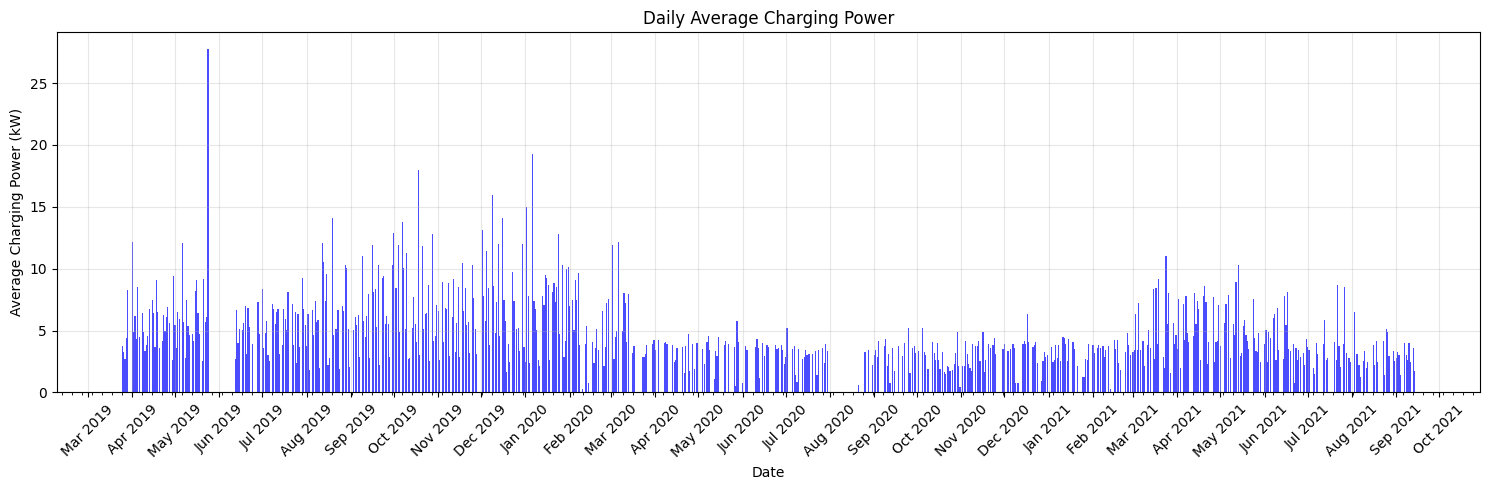

In [34]:
daily_power = hourly_power.resample('D').mean()

fig, ax = plt.subplots(figsize=(15,5))
ax.bar(daily_power.index, daily_power.values, color='blue', alpha=0.7, width=0.8)

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_minor_locator(mdates.WeekdayLocator(byweekday=mdates.MO))

ax.set_ylabel("Average Charging Power (kW)")
ax.set_xlabel("Date")
ax.set_title("Daily Average Charging Power")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Hourly profile (average per hour of day)

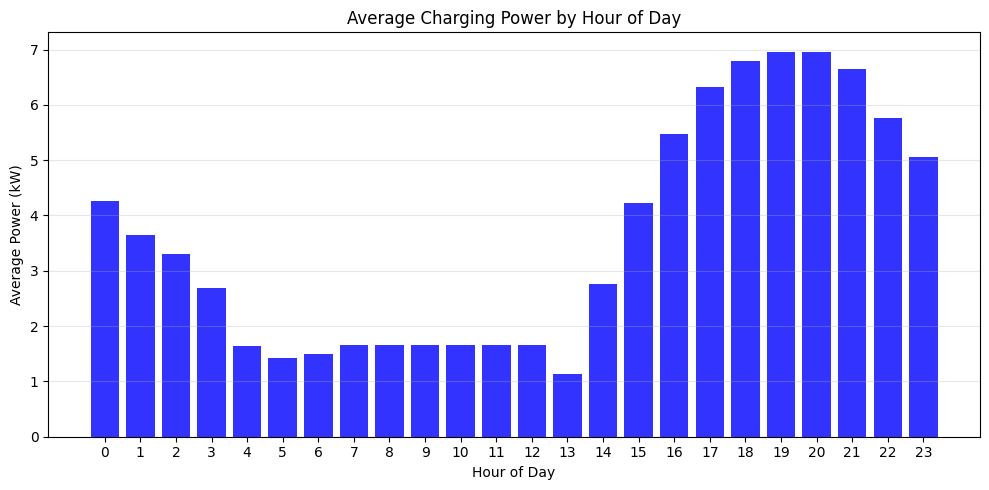

In [35]:
# Group by hour of day
hourly_avg = hourly_power.groupby(hourly_power.index.hour).mean()
hourly_avg = hourly_avg.reindex(range(24), fill_value=0)  # ensure 24 hours

fig, ax = plt.subplots(figsize=(10,5))
ax.bar(hourly_avg.index, hourly_avg.values, color='blue', alpha=0.8)

ax.set_xlabel("Hour of Day")
ax.set_ylabel("Average Power (kW)")
ax.set_title("Average Charging Power by Hour of Day")
ax.set_xticks(range(24))
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

Compute average demand per day of the week

In [36]:
import matplotlib.pyplot as plt

# Convert index to datetime if needed
hourly_power.index = pd.to_datetime(hourly_power.index)

# Compute average power per weekday
weekday_avg = hourly_power.groupby(hourly_power.index.dayofweek).mean()

# Map numbers to weekday names
weekday_names = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
weekday_avg.index = weekday_names

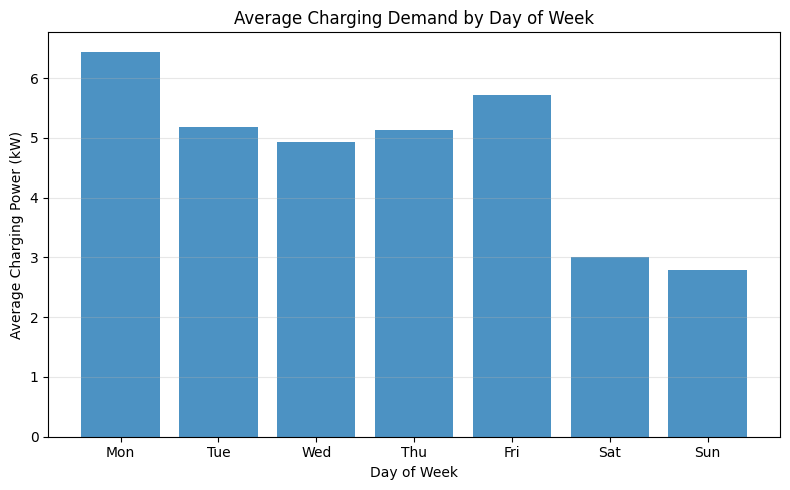

In [37]:
fig, ax = plt.subplots(figsize=(8,5))

ax.bar(weekday_avg.index, weekday_avg.values, alpha=0.8)

ax.set_xlabel("Day of Week")
ax.set_ylabel("Average Charging Power (kW)")
ax.set_title("Average Charging Demand by Day of Week")

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

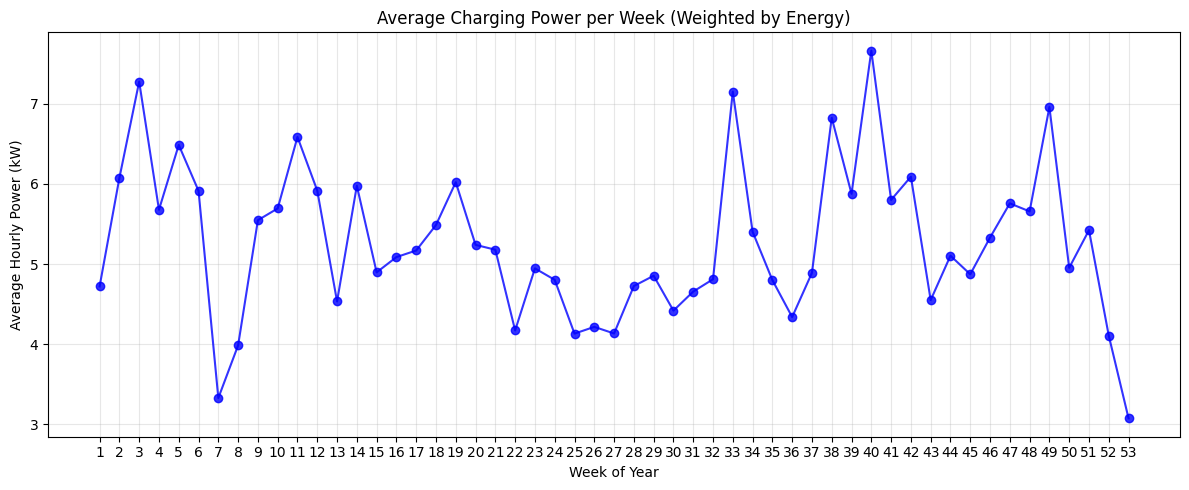

In [38]:
import pandas as pd
import matplotlib.pyplot as plt

# Make sure index is datetime
df_small.index = pd.to_datetime(df_small.index)

# Compute session duration in hours
df_small["session_hours"] = (df_small["doneChargingTime"] - df_small.index).dt.total_seconds() / 3600

# Compute hourly energy delivered
hourly_energy = {}

for idx, row in df_small.iterrows():
    start = idx
    end = row["doneChargingTime"]
    energy = row["kWhDelivered"]
    duration = (end - start).total_seconds()
    
    current = start
    while current < end:
        next_hour = (current + pd.Timedelta(hours=1)).floor("h")
        segment_end = min(end, next_hour)
        segment_seconds = (segment_end - current).total_seconds()
        energy_share = energy * (segment_seconds / duration)
        hour = current.floor("h")
        hourly_energy[hour] = hourly_energy.get(hour, 0) + energy_share
        current = segment_end

hourly_energy_series = pd.Series(hourly_energy).sort_index()

# Add week number
hourly_df = hourly_energy_series.to_frame(name="kWh")
hourly_df['week_of_year'] = hourly_df.index.isocalendar().week

# Compute average power per week (kW = kWh per 1 hour)
weekly_avg_power = hourly_df.groupby('week_of_year')['kWh'].mean()

# Plot
plt.figure(figsize=(12,5))
plt.plot(weekly_avg_power.index, weekly_avg_power.values, marker='o', color='blue', alpha=0.8)
plt.xlabel("Week of Year")
plt.ylabel("Average Hourly Power (kW)")
plt.title("Average Charging Power per Week (Weighted by Energy)")
plt.grid(alpha=0.3)
plt.xticks(weekly_avg_power.index)
plt.tight_layout()
plt.show()

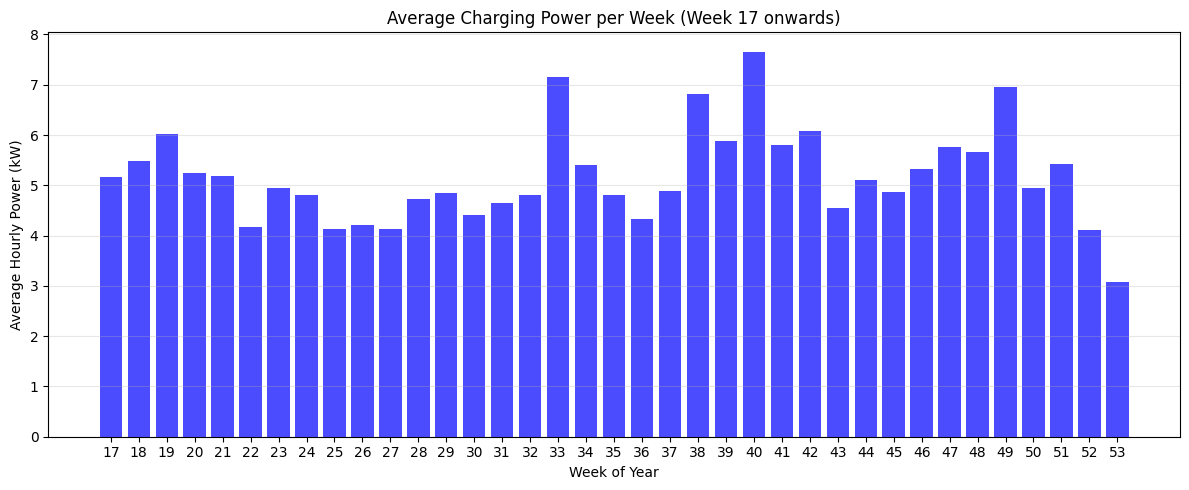

In [39]:
import matplotlib.pyplot as plt

# Filter weeks starting from week 17
weekly_subset = weekly_avg_power[weekly_avg_power.index >= 17]

# Bar plot
plt.figure(figsize=(12,5))
plt.bar(weekly_subset.index, weekly_subset.values, color='blue', alpha=0.7)
plt.xlabel("Week of Year")
plt.ylabel("Average Hourly Power (kW)")
plt.title("Average Charging Power per Week (Week 17 onwards)")
plt.grid(alpha=0.3, axis='y')
plt.xticks(weekly_subset.index)
plt.tight_layout()
plt.show()

Outlier Removal Using IQR

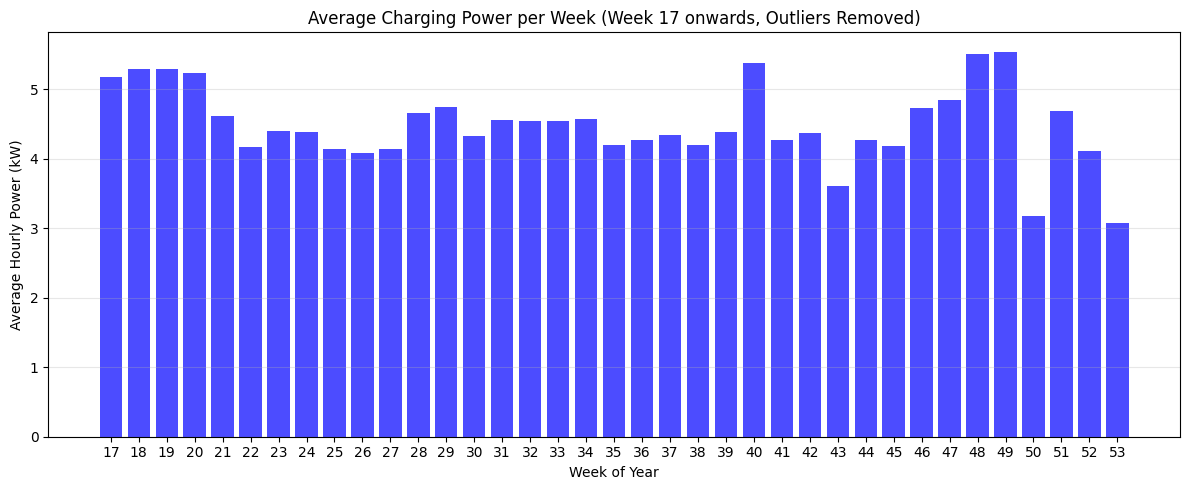

In [40]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Step 1: Remove outliers using IQR ---
Q1 = hourly_energy_series.quantile(0.25)
Q3 = hourly_energy_series.quantile(0.75)
IQR = Q3 - Q1
filtered_series = hourly_energy_series[(hourly_energy_series >= Q1 - 1.5*IQR) &
                                       (hourly_energy_series <= Q3 + 1.5*IQR)]

# --- Step 2: Convert to DataFrame and add week number ---
hourly_df = filtered_series.to_frame(name="kWh")
hourly_df['week_of_year'] = hourly_df.index.isocalendar().week

# --- Step 3: Compute weekly average power ---
weekly_avg_power = hourly_df.groupby('week_of_year')['kWh'].mean()

# --- Step 4: Select weeks >= 17 ---
weekly_subset = weekly_avg_power[weekly_avg_power.index >= 17]

# --- Step 5: Bar plot ---
plt.figure(figsize=(12,5))
plt.bar(weekly_subset.index, weekly_subset.values, color='blue', alpha=0.7)
plt.xlabel("Week of Year")
plt.ylabel("Average Hourly Power (kW)")
plt.title("Average Charging Power per Week (Week 17 onwards, Outliers Removed)")
plt.grid(alpha=0.3, axis='y')
plt.xticks(weekly_subset.index)
plt.tight_layout()
plt.show()

At the hourly level (original data)

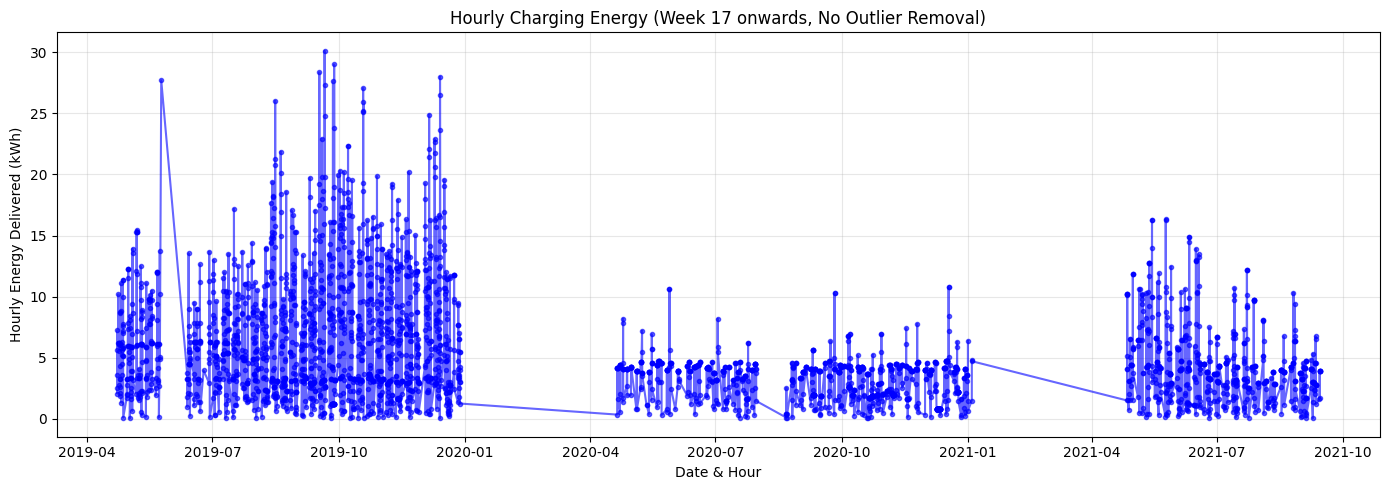

In [41]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Step 1: Convert original hourly series to DataFrame and add week number ---
hourly_df = hourly_energy_series.to_frame(name="kWh")
hourly_df['week_of_year'] = hourly_df.index.isocalendar().week

# --- Step 2: Keep only hours from week 17 onwards ---
hourly_subset = hourly_df[hourly_df['week_of_year'] >= 17]

# --- Step 3: Plot hourly data ---
plt.figure(figsize=(14,5))
plt.plot(hourly_subset.index, hourly_subset['kWh'], marker='.', linestyle='-', color='blue', alpha=0.6)
plt.xlabel("Date & Hour")
plt.ylabel("Hourly Energy Delivered (kWh)")
plt.title("Hourly Charging Energy (Week 17 onwards, No Outlier Removal)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

At the hourly level (outliers removed)

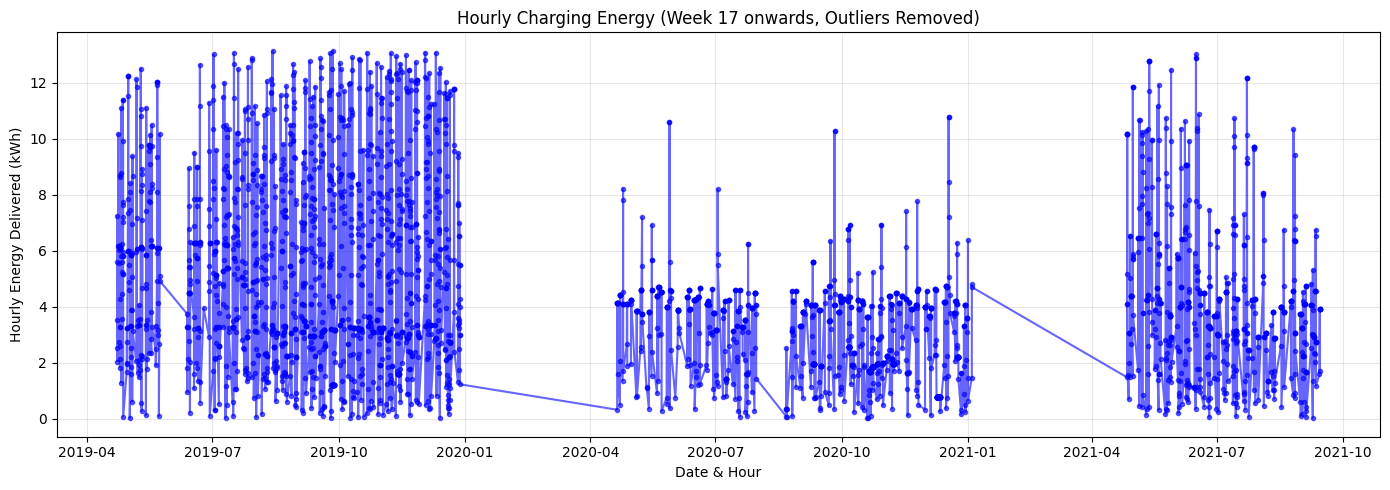

In [42]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Step 1: Remove outliers from hourly data using IQR ---
Q1 = hourly_energy_series.quantile(0.25)
Q3 = hourly_energy_series.quantile(0.75)
IQR = Q3 - Q1
filtered_hourly = hourly_energy_series[(hourly_energy_series >= Q1 - 1.5*IQR) &
                                       (hourly_energy_series <= Q3 + 1.5*IQR)]

# --- Step 2: Convert to DataFrame and add week number ---
hourly_df = filtered_hourly.to_frame(name="kWh")
hourly_df['week_of_year'] = hourly_df.index.isocalendar().week

# --- Step 3: Keep only hours from week 17 onwards ---
hourly_subset = hourly_df[hourly_df['week_of_year'] >= 17]

# --- Step 4: Plot hourly data ---
plt.figure(figsize=(14,5))
plt.plot(hourly_subset.index, hourly_subset['kWh'], marker='.', linestyle='-', color='blue', alpha=0.6)
plt.xlabel("Date & Hour")
plt.ylabel("Hourly Energy Delivered (kWh)")
plt.title("Hourly Charging Energy (Week 17 onwards, Outliers Removed)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Min-Max Normalization

In [43]:
# Min-max normalization of hourly energy
hourly_subset['kWh_norm'] = (hourly_subset['kWh'] - hourly_subset['kWh'].min()) / \
                             (hourly_subset['kWh'].max() - hourly_subset['kWh'].min())

C:\Users\betsie_0410\AppData\Local\Temp\ipykernel_16480\3969204589.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hourly_subset['kWh_norm'] = (hourly_subset['kWh'] - hourly_subset['kWh'].min()) / \


Feature Addition (as done in the paper)

In [44]:
hourly_subset['ConnectionHour'] = hourly_subset.index.hour
hourly_subset['DayofWeek'] = hourly_subset.index.dayofweek   # 0=Monday, 6=Sunday
hourly_subset['Week'] = hourly_subset.index.isocalendar().week
hourly_subset['WorkingStatus'] = hourly_subset['DayofWeek'].apply(lambda x: 0 if x>=5 else 1)  # 0=holiday, 1=working day

# Hourly average demand (average energy for that hour across all days)
hourly_subset['HourlyAverageDemand'] = hourly_subset.groupby('ConnectionHour')['kWh'].transform('mean')

# Previous 24-hour average demand
hourly_subset['Previous24HrAverageDemand'] = hourly_subset['kWh'].rolling(24, min_periods=1).mean()

C:\Users\betsie_0410\AppData\Local\Temp\ipykernel_16480\3768178214.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hourly_subset['ConnectionHour'] = hourly_subset.index.hour
C:\Users\betsie_0410\AppData\Local\Temp\ipykernel_16480\3768178214.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hourly_subset['DayofWeek'] = hourly_subset.index.dayofweek   # 0=Monday, 6=Sunday
C:\Users\betsie_0410\AppData\Local\Temp\ipykernel_16480\3768178214.py:3: SettingWithCopyWarning: 
A value is trying to be set on a co

Plot Normalized Hourly Data

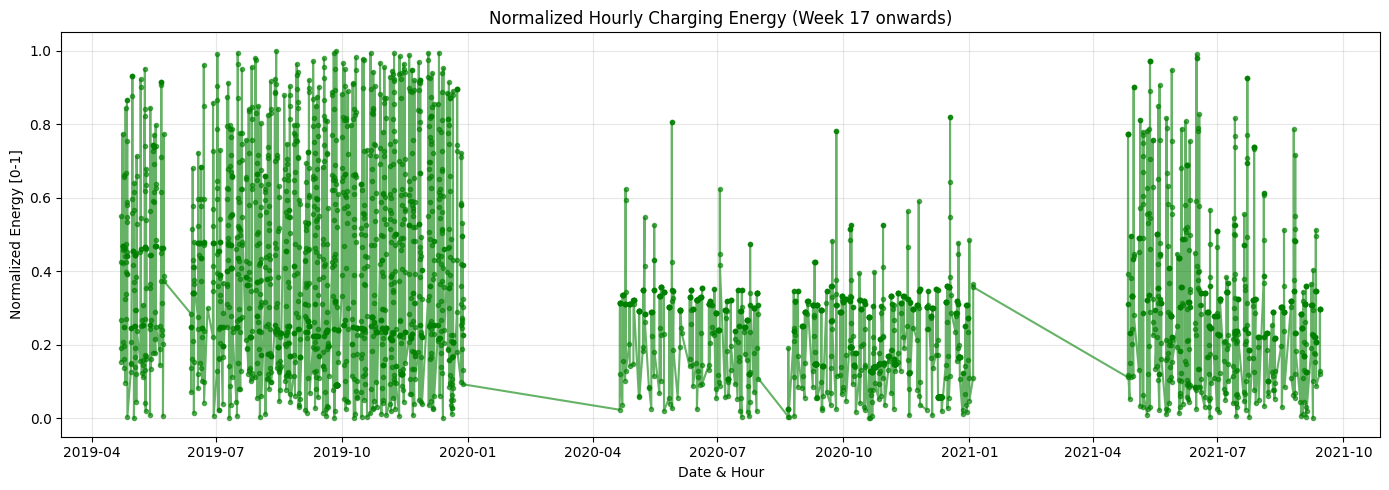

In [45]:
plt.figure(figsize=(14,5))
plt.plot(hourly_subset.index, hourly_subset['kWh_norm'], marker='.', linestyle='-', color='green', alpha=0.6)
plt.xlabel("Date & Hour")
plt.ylabel("Normalized Energy [0-1]")
plt.title("Normalized Hourly Charging Energy (Week 17 onwards)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Data partitioning for LSTM:

-Training: data until 31 Oct 2018
-Validation: Nov–Dec 2018
-Test: Jan 2019

In [46]:
# Training: e.g., week 17 to Oct
train_data = hourly_subset[hourly_subset.index <= '2018-10-31']

# Validation: Nov–Dec
val_data = hourly_subset[(hourly_subset.index >= '2018-11-01') & (hourly_subset.index <= '2018-12-31')]

# Test: empty because you don’t have Jan 2019
test_data = hourly_subset[hourly_subset.index >= '2019-01-01']

Do a train/validation split within the available data

In [47]:
# Keep hours from week 17 onwards and include January 2019
hourly_subset = hourly_df[hourly_df.index >= '2018-04-23']  # week 17 of 2018

In [48]:
hourly_subset = hourly_df[hourly_df.index >= '2018-04-23']  # adjust to actual start date

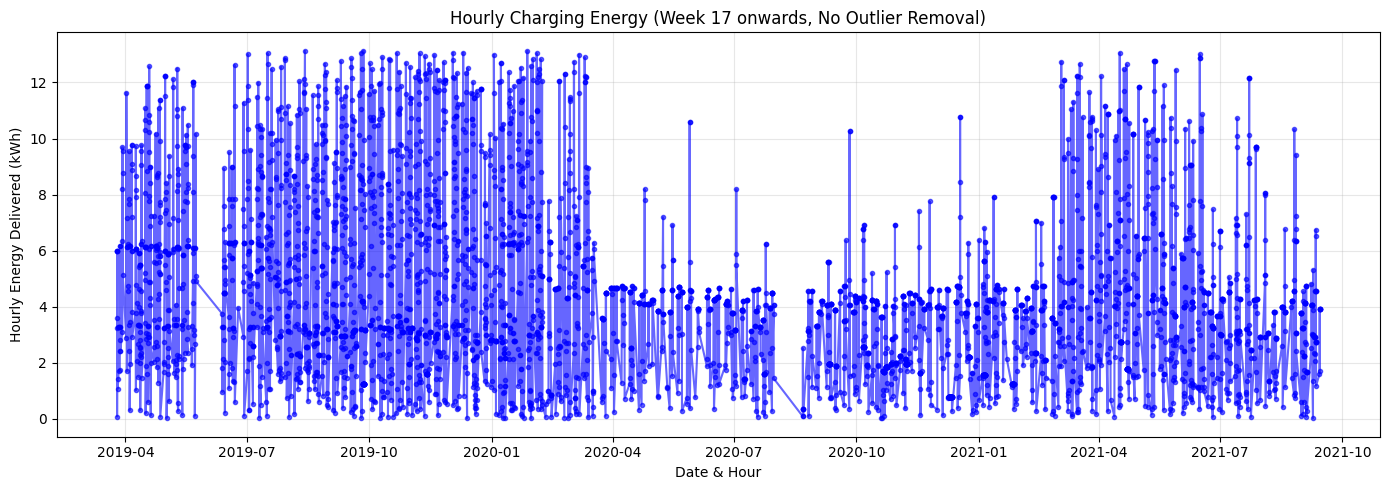

In [49]:
plt.figure(figsize=(14,5))
plt.plot(hourly_subset.index, hourly_subset['kWh'], marker='.', linestyle='-', color='blue', alpha=0.6)
plt.xlabel("Date & Hour")
plt.ylabel("Hourly Energy Delivered (kWh)")
plt.title("Hourly Charging Energy (Week 17 onwards, No Outlier Removal)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

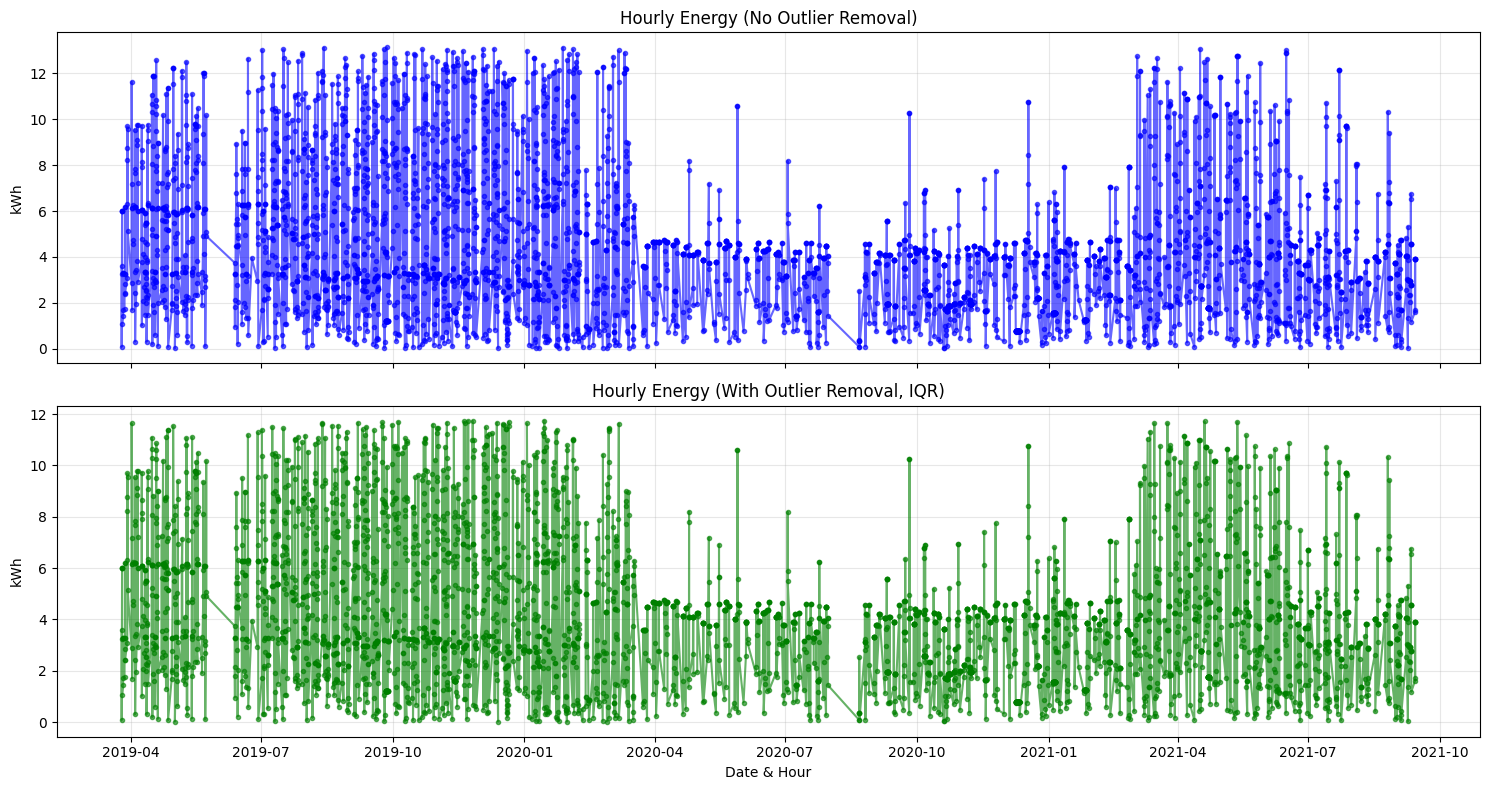

In [50]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import numpy as np

# --- Assume hourly_df already exists ---
# Keep all hours from week 17 onwards
hourly_subset = hourly_df[hourly_df.index >= '2018-04-23']  # week 17 start

# --- 1️⃣ Without outlier removal ---
hourly_no_outlier_removal = hourly_subset.copy()

# --- 2️⃣ With outlier removal using IQR ---
Q1 = hourly_subset['kWh'].quantile(0.25)
Q3 = hourly_subset['kWh'].quantile(0.75)
IQR = Q3 - Q1
hourly_with_outlier_removal = hourly_subset[
    (hourly_subset['kWh'] >= Q1 - 1.5*IQR) & 
    (hourly_subset['kWh'] <= Q3 + 1.5*IQR)
]

# --- Plot comparison ---
fig, axs = plt.subplots(2, 1, figsize=(15,8), sharex=True)

# No outlier removal
axs[0].plot(hourly_no_outlier_removal.index, hourly_no_outlier_removal['kWh'],
            marker='.', linestyle='-', color='blue', alpha=0.6)
axs[0].set_title("Hourly Energy (No Outlier Removal)")
axs[0].set_ylabel("kWh")
axs[0].grid(alpha=0.3)

# With outlier removal
axs[1].plot(hourly_with_outlier_removal.index, hourly_with_outlier_removal['kWh'],
            marker='.', linestyle='-', color='green', alpha=0.6)
axs[1].set_title("Hourly Energy (With Outlier Removal, IQR)")
axs[1].set_xlabel("Date & Hour")
axs[1].set_ylabel("kWh")
axs[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

LSTM workflow using your hourly energy data. We’ll include train/validation/test split, optional outlier removal, and min-max normalization, just like the paper describes. We’ll prepare the data for a multivariate LSTM with features like hour of day, day of week, and previous 24-hour averages.

In [298]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print(tf.constant([[1,2],[3,4]]))

TensorFlow version: 2.21.0
tf.Tensor(
[[1 2]
 [3 4]], shape=(2, 2), dtype=int32)


Epoch 1/30


c:\Users\betsie_0410\energiapy\.conda\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0736 - val_loss: 0.0370
Epoch 2/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0410 - val_loss: 0.0477
Epoch 3/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0365 - val_loss: 0.0460
Epoch 4/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0343 - val_loss: 0.0434
Epoch 5/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0304 - val_loss: 0.0392
Epoch 6/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0246 - val_loss: 0.0344
Epoch 7/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0213 - val_loss: 0.0333
Epoch 8/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0199 - val_loss: 0.0322
Epoch 9/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0197 - val_loss: 0.0372
Epoch 10/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0192 - val_loss: 0.0354
Epoch 11/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0185 - val_loss: 0.0365
Epoch 12/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0179 - val_l

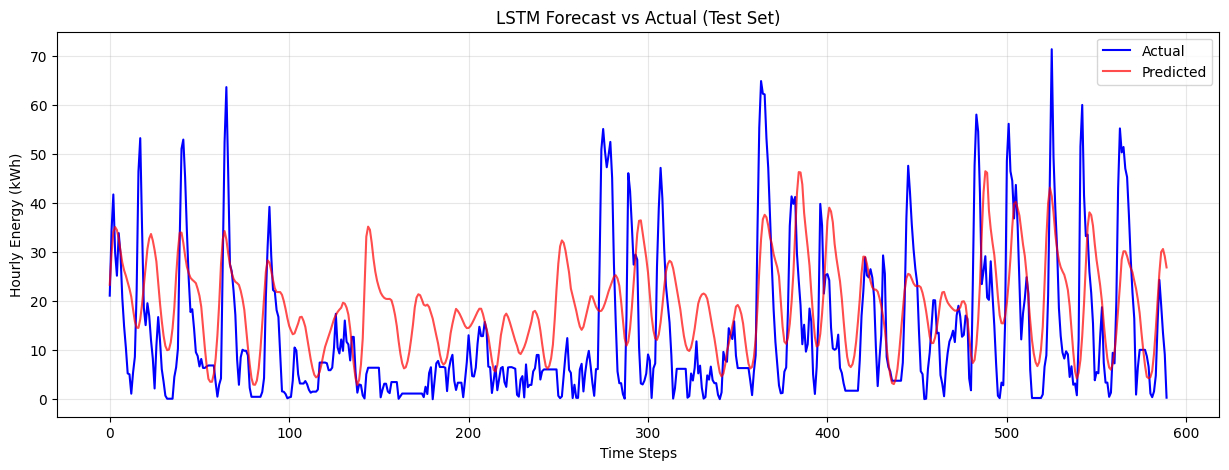

In [299]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, ReLU
from tensorflow.keras.callbacks import EarlyStopping

# -----------------------------
# 1️⃣ Prepare data
# -----------------------------
# Assume hourly_df exists with columns: ['kWh'], index=datetime
hourly_subset = hourly_df[hourly_df.index >= '2018-04-23'].copy()  # week 17 onwards

# Optional: remove outliers using IQR
Q1 = hourly_subset['kWh'].quantile(0.25)
Q3 = hourly_subset['kWh'].quantile(0.75)
IQR = Q3 - Q1
hourly_subset = hourly_subset[(hourly_subset['kWh'] >= Q1 - 1.5*IQR) &
                              (hourly_subset['kWh'] <= Q3 + 1.5*IQR)]

# Add features
hourly_subset['ConnectionHour'] = hourly_subset.index.hour
hourly_subset['DayOfWeek'] = hourly_subset.index.dayofweek
hourly_subset['Previous24HrAvg'] = hourly_subset['kWh'].rolling(24, min_periods=1).mean()

features = ['ConnectionHour', 'DayOfWeek', 'Previous24HrAvg', 'kWh']  # multivariate including target

# -----------------------------
# 2️⃣ Train/Val/Test Split
# -----------------------------
train_df = hourly_subset[hourly_subset.index <= '2018-10-31']
val_df   = hourly_subset[(hourly_subset.index >= '2018-11-01') & (hourly_subset.index <= '2018-12-31')]
test_df  = hourly_subset[hourly_subset.index >= '2018-12-15']  # last 2 weeks as test

# -----------------------------
# 3️⃣ Normalize
# -----------------------------
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_df[features])
val_scaled   = scaler.transform(val_df[features])
test_scaled  = scaler.transform(test_df[features])

# -----------------------------
# 4️⃣ Create sequences
# -----------------------------
def create_sequences(data, seq_length=48):
    X, y = [], []
    for i in range(seq_length, len(data)):
        X.append(data[i-seq_length:i, :-1])
        y.append(data[i, -1])
    return np.array(X), np.array(y)

seq_length = 48
X_train, y_train = create_sequences(train_scaled, seq_length)
X_val, y_val     = create_sequences(val_scaled, seq_length)
X_test, y_test   = create_sequences(test_scaled, seq_length)

# -----------------------------
# 5️⃣ Build LSTM model (Keras)
# -----------------------------
input_shape = X_train.shape[1:]  # (seq_length, num_features-1)

model = Sequential([
    LSTM(50, input_shape=input_shape, return_sequences=False),
    Dense(50),
    ReLU(),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')

# Optional early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# -----------------------------
# 6️⃣ Train
# -----------------------------
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=192,
    callbacks=[early_stop],
    verbose=1
)

# -----------------------------
# 7️⃣ Test predictions
# -----------------------------
test_pred = model.predict(X_test)

# Inverse scaling for plotting
y_test_inv = scaler.inverse_transform(
    np.hstack([np.zeros((y_test.shape[0], len(features)-1)), y_test.reshape(-1,1)])
)[:,-1]

test_pred_inv = scaler.inverse_transform(
    np.hstack([np.zeros((test_pred.shape[0], len(features)-1)), test_pred])
)[:,-1]

# -----------------------------
# 8️⃣ Plot
# -----------------------------
plt.figure(figsize=(15,5))
plt.plot(y_test_inv, label='Actual', color='blue')
plt.plot(test_pred_inv, label='Predicted', color='red', alpha=0.7)
plt.title("LSTM Forecast vs Actual (Test Set)")
plt.xlabel("Time Steps")
plt.ylabel("Hourly Energy (kWh)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Epoch 1/50


C:\Users\betsie_0410\AppData\Local\Temp\ipykernel_18288\1545081451.py:26: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  hourly_subset['lag_1'] = hourly_subset['kWh'].shift(1).fillna(method='bfill')
C:\Users\betsie_0410\AppData\Local\Temp\ipykernel_18288\1545081451.py:27: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  hourly_subset['lag_2'] = hourly_subset['kWh'].shift(2).fillna(method='bfill')
C:\Users\betsie_0410\AppData\Local\Temp\ipykernel_18288\1545081451.py:28: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  hourly_subset['lag_3'] = hourly_subset['kWh'].shift(3).fillna(method='bfill')
c:\Users\betsie_0410\energiapy\.conda\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_d

66/66 - 5s - 71ms/step - loss: 0.3468 - val_loss: 0.3945
Epoch 2/50
66/66 - 3s - 48ms/step - loss: 0.2862 - val_loss: 0.4727
Epoch 3/50
66/66 - 3s - 48ms/step - loss: 0.2701 - val_loss: 0.4119
Epoch 4/50
66/66 - 3s - 48ms/step - loss: 0.2623 - val_loss: 0.3460
Epoch 5/50
66/66 - 3s - 48ms/step - loss: 0.2528 - val_loss: 0.3517
Epoch 6/50
66/66 - 3s - 47ms/step - loss: 0.2444 - val_loss: 0.3691
Epoch 7/50
66/66 - 3s - 48ms/step - loss: 0.2466 - val_loss: 0.3850
Epoch 8/50
66/66 - 3s - 48ms/step - loss: 0.2432 - val_loss: 0.3470
Epoch 9/50
66/66 - 3s - 48ms/step - loss: 0.2406 - val_loss: 0.3638
Epoch 10/50
66/66 - 3s - 47ms/step - loss: 0.2357 - val_loss: 0.3455
Epoch 11/50
66/66 - 3s - 48ms/step - loss: 0.2327 - val_loss: 0.3081
Epoch 12/50
66/66 - 3s - 48ms/step - loss: 0.2294 - val_loss: 0.3340
Epoch 13/50
66/66 - 3s - 49ms/step - loss: 0.2299 - val_loss: 0.3152
Epoch 14/50
66/66 - 3s - 48ms/step - loss: 0.2301 - val_loss: 0.3418
Epoch 15/50
66/66 - 3s - 49ms/step - loss: 0.2272 - va

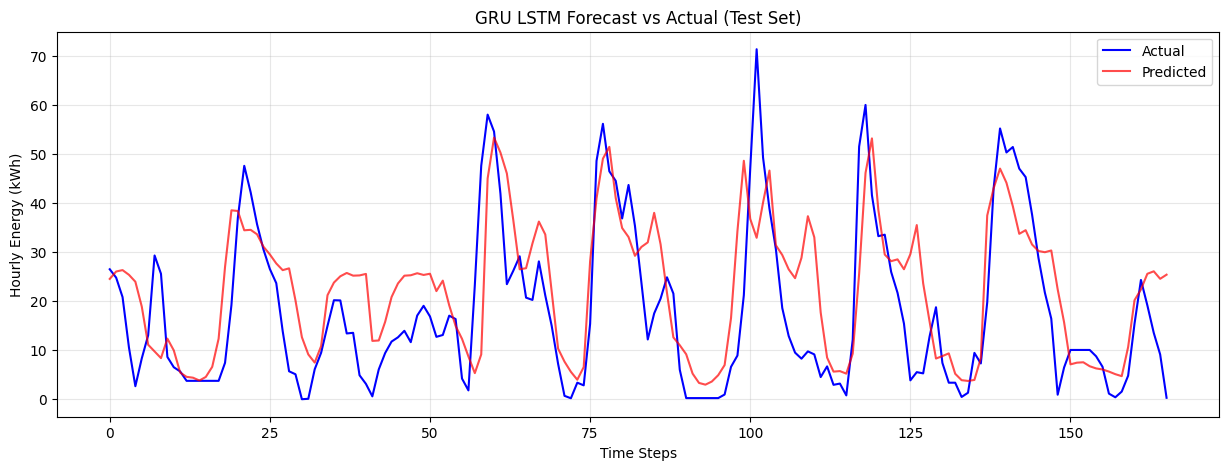

In [304]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout

# -----------------------------
# 1️⃣ Prepare data
# -----------------------------
hourly_subset = hourly_df[hourly_df.index >= '2018-04-23'].copy()  # week 17 onwards

# Optional: remove outliers using IQR
Q1 = hourly_subset['kWh'].quantile(0.25)
Q3 = hourly_subset['kWh'].quantile(0.75)
IQR = Q3 - Q1
hourly_subset = hourly_subset[(hourly_subset['kWh'] >= Q1 - 1.5*IQR) &
                              (hourly_subset['kWh'] <= Q3 + 1.5*IQR)]

# Add time features
hourly_subset['Hour'] = hourly_subset.index.hour
hourly_subset['DayOfWeek'] = hourly_subset.index.dayofweek

# Add lag features
hourly_subset['lag_1'] = hourly_subset['kWh'].shift(1).fillna(method='bfill')
hourly_subset['lag_2'] = hourly_subset['kWh'].shift(2).fillna(method='bfill')
hourly_subset['lag_3'] = hourly_subset['kWh'].shift(3).fillna(method='bfill')

features = ['Hour', 'DayOfWeek', 'lag_1', 'lag_2', 'lag_3', 'kWh']

# -----------------------------
# 2️⃣ Train/Val/Test Split
# -----------------------------
# Training: up to 31 October 2018
train_df = hourly_subset[hourly_subset.index <= '2018-10-31']
# Validation: November + December 2018
val_df   = hourly_subset[(hourly_subset.index >= '2018-11-01') & (hourly_subset.index <= '2018-12-31')]
# Test: January 2019
test_df  = hourly_subset[(hourly_subset.index >= '2019-01-01') & (hourly_subset.index <= '2019-01-31')]

# -----------------------------
# 3️⃣ Normalize
# -----------------------------
scaler = RobustScaler()
train_scaled = scaler.fit_transform(train_df[features])
val_scaled   = scaler.transform(val_df[features])
test_scaled  = scaler.transform(test_df[features])

# -----------------------------
# 4️⃣ Create sequences
# -----------------------------
def create_sequences(data, seq_length=168):
    X, y = [], []
    for i in range(seq_length, len(data)):
        X.append(data[i-seq_length:i, :-1])
        y.append(data[i, -1])
    return np.array(X), np.array(y)

seq_length = 168
X_train, y_train = create_sequences(train_scaled, seq_length)
X_val, y_val     = create_sequences(val_scaled, seq_length)
X_test, y_test   = create_sequences(test_scaled, seq_length)

# -----------------------------
# 5️⃣ Build LSTM/GRU model
# -----------------------------
model = Sequential([
    GRU(64, return_sequences=True, input_shape=(seq_length, X_train.shape[2])),
    Dropout(0.2),
    GRU(32),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])

model.compile(optimizer=tf.keras.optimizers.Adam(0.001), loss='mae')

# -----------------------------
# 6️⃣ Train
# -----------------------------
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=64,
    verbose=2
)

# -----------------------------
# 7️⃣ Test predictions
# -----------------------------
test_pred = model.predict(X_test)

# Inverse scaling for plotting
target_scaler = RobustScaler()
y_train_scaled = target_scaler.fit_transform(train_df[['kWh']])
y_val_scaled   = target_scaler.transform(val_df[['kWh']])
y_test_scaled  = target_scaler.transform(test_df[['kWh']])

# After predicting
test_pred_inv = target_scaler.inverse_transform(test_pred)
y_test_inv    = target_scaler.inverse_transform(y_test.reshape(-1,1))

# -----------------------------
# 8️⃣ Plot
# -----------------------------
plt.figure(figsize=(15,5))
plt.plot(y_test_inv, label='Actual', color='blue')
plt.plot(test_pred_inv, label='Predicted', color='red', alpha=0.7)
plt.title("GRU LSTM Forecast vs Actual (Test Set)")
plt.xlabel("Time Steps")
plt.ylabel("Hourly Energy (kWh)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Epoch 1/50


C:\Users\betsie_0410\AppData\Local\Temp\ipykernel_18288\3454896543.py:27: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  hourly_subset['lag_1'] = hourly_subset['kWh'].shift(1).fillna(method='bfill')
C:\Users\betsie_0410\AppData\Local\Temp\ipykernel_18288\3454896543.py:28: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  hourly_subset['lag_24'] = hourly_subset['kWh'].shift(24).fillna(method='bfill')  # previous day same hour
c:\Users\betsie_0410\energiapy\.conda\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


66/66 - 5s - 72ms/step - loss: 0.3536 - val_loss: 0.3727
Epoch 2/50
66/66 - 3s - 49ms/step - loss: 0.2887 - val_loss: 0.3527
Epoch 3/50
66/66 - 3s - 53ms/step - loss: 0.2779 - val_loss: 0.3734
Epoch 4/50
66/66 - 3s - 51ms/step - loss: 0.2645 - val_loss: 0.3816
Epoch 5/50
66/66 - 4s - 53ms/step - loss: 0.2572 - val_loss: 0.3300
Epoch 6/50
66/66 - 3s - 50ms/step - loss: 0.2502 - val_loss: 0.3001
Epoch 7/50
66/66 - 3s - 49ms/step - loss: 0.2448 - val_loss: 0.3140
Epoch 8/50
66/66 - 4s - 53ms/step - loss: 0.2411 - val_loss: 0.3391
Epoch 9/50
66/66 - 4s - 55ms/step - loss: 0.2393 - val_loss: 0.3179
Epoch 10/50
66/66 - 3s - 51ms/step - loss: 0.2354 - val_loss: 0.3123
Epoch 11/50
66/66 - 3s - 52ms/step - loss: 0.2371 - val_loss: 0.2878
Epoch 12/50
66/66 - 3s - 51ms/step - loss: 0.2349 - val_loss: 0.3191
Epoch 13/50
66/66 - 4s - 56ms/step - loss: 0.2339 - val_loss: 0.2833
Epoch 14/50
66/66 - 3s - 52ms/step - loss: 0.2334 - val_loss: 0.3138
Epoch 15/50
66/66 - 3s - 52ms/step - loss: 0.2261 - va

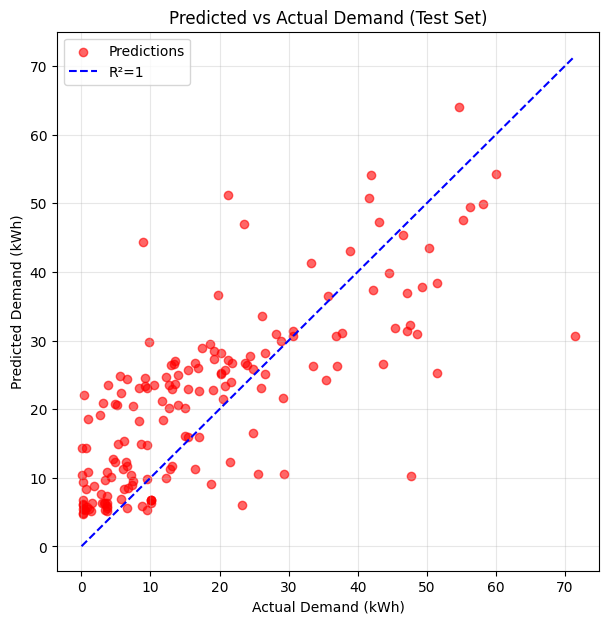

In [308]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout

# -----------------------------
# 1️⃣ Prepare data
# -----------------------------
hourly_subset = hourly_df[hourly_df.index >= '2018-04-23'].copy()

# Remove outliers using IQR
Q1 = hourly_subset['kWh'].quantile(0.25)
Q3 = hourly_subset['kWh'].quantile(0.75)
IQR = Q3 - Q1
hourly_subset = hourly_subset[(hourly_subset['kWh'] >= Q1 - 1.5*IQR) &
                              (hourly_subset['kWh'] <= Q3 + 1.5*IQR)]

# Time features
hourly_subset['Hour'] = hourly_subset.index.hour
hourly_subset['DayOfWeek'] = hourly_subset.index.dayofweek

# Lag features
hourly_subset['lag_1'] = hourly_subset['kWh'].shift(1).fillna(method='bfill')
hourly_subset['lag_24'] = hourly_subset['kWh'].shift(24).fillna(method='bfill')  # previous day same hour
hourly_subset['rolling_24'] = hourly_subset['kWh'].rolling(24, min_periods=1).mean()

features = ['Hour', 'DayOfWeek', 'lag_1', 'lag_24', 'rolling_24']
target = 'kWh'

# -----------------------------
# 2️⃣ Train/Val/Test Split
# -----------------------------
train_df = hourly_subset[hourly_subset.index <= '2018-10-31']
val_df   = hourly_subset[(hourly_subset.index >= '2018-11-01') & (hourly_subset.index <= '2018-12-31')]
test_df  = hourly_subset[(hourly_subset.index >= '2019-01-01') & (hourly_subset.index <= '2019-01-31')]

# -----------------------------
# 3️⃣ Scaling
# -----------------------------
feature_scaler = RobustScaler()
X_train_scaled = feature_scaler.fit_transform(train_df[features])
X_val_scaled   = feature_scaler.transform(val_df[features])
X_test_scaled  = feature_scaler.transform(test_df[features])

target_scaler = RobustScaler()
y_train_scaled = target_scaler.fit_transform(train_df[[target]])
y_val_scaled   = target_scaler.transform(val_df[[target]])
y_test_scaled  = target_scaler.transform(test_df[[target]])

# -----------------------------
# 4️⃣ Create sequences
# -----------------------------
def create_sequences(X, y, seq_length=168):
    X_seq, y_seq = [], []
    for i in range(seq_length, len(X)):
        X_seq.append(X[i-seq_length:i, :])
        y_seq.append(y[i, 0])
    return np.array(X_seq), np.array(y_seq)

seq_length = 168
X_train, y_train = create_sequences(X_train_scaled, y_train_scaled, seq_length)
X_val, y_val     = create_sequences(X_val_scaled, y_val_scaled, seq_length)
X_test, y_test   = create_sequences(X_test_scaled, y_test_scaled, seq_length)

# -----------------------------
# 5️⃣ Build GRU model
# -----------------------------
model = Sequential([
    GRU(64, return_sequences=True, input_shape=(seq_length, X_train.shape[2])),
    Dropout(0.2),
    GRU(32),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])

model.compile(optimizer=tf.keras.optimizers.Adam(0.001), loss='mae')

# -----------------------------
# 6️⃣ Train
# -----------------------------
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=64,
    verbose=2
)

# -----------------------------
# 7️⃣ Predictions & Inverse scaling
# -----------------------------
train_pred = model.predict(X_train)
val_pred   = model.predict(X_val)
test_pred  = model.predict(X_test)

# Inverse scale
y_train_inv = target_scaler.inverse_transform(y_train.reshape(-1,1))
train_pred_inv = target_scaler.inverse_transform(train_pred)

y_val_inv = target_scaler.inverse_transform(y_val.reshape(-1,1))
val_pred_inv = target_scaler.inverse_transform(val_pred)

y_test_inv = target_scaler.inverse_transform(y_test.reshape(-1,1))
test_pred_inv = target_scaler.inverse_transform(test_pred)

# -----------------------------
# 8️⃣ Metrics
# -----------------------------
def compute_metrics(y_true, y_pred):
    errors = y_pred.flatten() - y_true.flatten()
    ME   = np.mean(errors)
    MAE  = np.mean(np.abs(errors))
    RMSE = np.sqrt(np.mean(errors**2))
    SMAPE = np.mean(2 * np.abs(errors) / (np.abs(y_pred.flatten()) + np.abs(y_true.flatten()))) * 100
    R2 = r2_score(y_true, y_pred)
    return ME, MAE, RMSE, SMAPE, R2

sets = {'Train': (y_train_inv, train_pred_inv),
        'Validation': (y_val_inv, val_pred_inv),
        'Test': (y_test_inv, test_pred_inv)}

print("Metrics:")
for name, (y_true, y_pred) in sets.items():
    ME, MAE, RMSE, SMAPE, R2 = compute_metrics(y_true, y_pred)
    print(f"{name}: ME={ME:.2f}, MAE={MAE:.2f}, RMSE={RMSE:.2f}, SMAPE={SMAPE:.2f}%, R²={R2:.3f}")

# -----------------------------
# 9️⃣ Parity plot (Predicted vs Actual) for test set
# -----------------------------
plt.figure(figsize=(7,7))
plt.scatter(y_test_inv, test_pred_inv, alpha=0.6, color='red', label='Predictions')
plt.plot([y_test_inv.min(), y_test_inv.max()],
         [y_test_inv.min(), y_test_inv.max()],
         color='blue', linestyle='--', label='R²=1')
plt.xlabel("Actual Demand (kWh)")
plt.ylabel("Predicted Demand (kWh)")
plt.title("Predicted vs Actual Demand (Test Set)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

R² = 0.5327


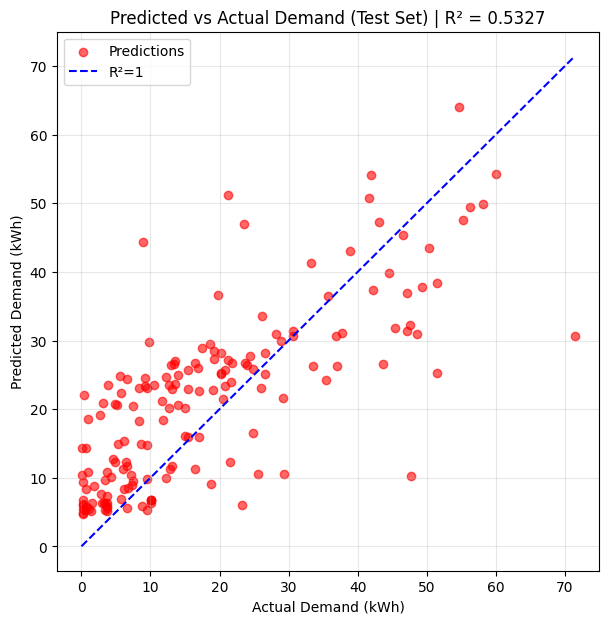

In [309]:
from sklearn.metrics import r2_score

# Compute R²
r2 = r2_score(y_test_inv, test_pred_inv)
print(f"R² = {r2:.4f}")

# -----------------------------
# Parity plot
# -----------------------------
plt.figure(figsize=(7,7))
plt.scatter(y_test_inv, test_pred_inv, alpha=0.6, color='red', label='Predictions')
plt.plot([y_test_inv.min(), y_test_inv.max()],
         [y_test_inv.min(), y_test_inv.max()],
         color='blue', linestyle='--', label='R²=1')
plt.xlabel("Actual Demand (kWh)")
plt.ylabel("Predicted Demand (kWh)")
plt.title(f"Predicted vs Actual Demand (Test Set) | R² = {r2:.4f}")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Performance metrics for the configurations

In [310]:
import numpy as np

# y_test_inv → actual
# test_pred_inv → predicted

errors = test_pred_inv.flatten() - y_test_inv.flatten()

ME   = np.mean(errors)
MAE  = np.mean(np.abs(errors))
RMSE = np.sqrt(np.mean(errors**2))
MAPE = np.mean(np.abs(errors / y_test_inv.flatten())) * 100  # in %

print(f"Mean Error (ME): {ME:.3f} kWh")
print(f"Mean Absolute Error (MAE): {MAE:.3f} kWh")
print(f"Root Mean Squared Error (RMSE): {RMSE:.3f} kWh")
print(f"Mean Absolute Percentage Error (MAPE): {MAPE:.2f}%")

Mean Error (ME): 3.304 kWh
Mean Absolute Error (MAE): 8.491 kWh
Root Mean Squared Error (RMSE): 10.970 kWh
Mean Absolute Percentage Error (MAPE): 608.48%


# Plot train / validation / test split

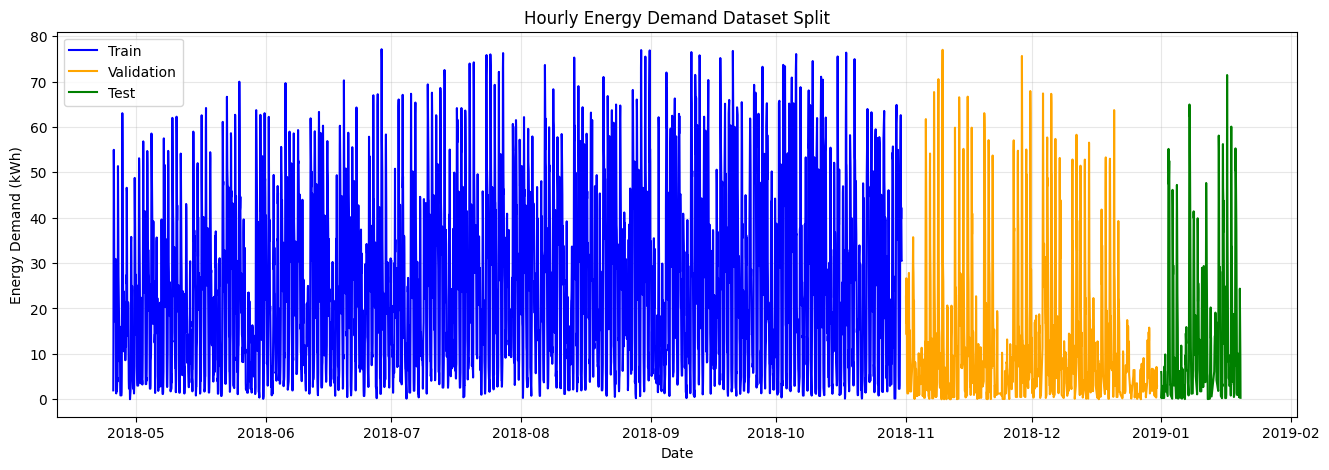

In [312]:
# -----------------------------
# Plot train / validation / test split
# -----------------------------
plt.figure(figsize=(16,5))

plt.plot(train_df.index, train_df['kWh'], label='Train', color='blue')
plt.plot(val_df.index, val_df['kWh'], label='Validation', color='orange')
plt.plot(test_df.index, test_df['kWh'], label='Test', color='green')

plt.title("Hourly Energy Demand Dataset Split")
plt.xlabel("Date")
plt.ylabel("Energy Demand (kWh)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

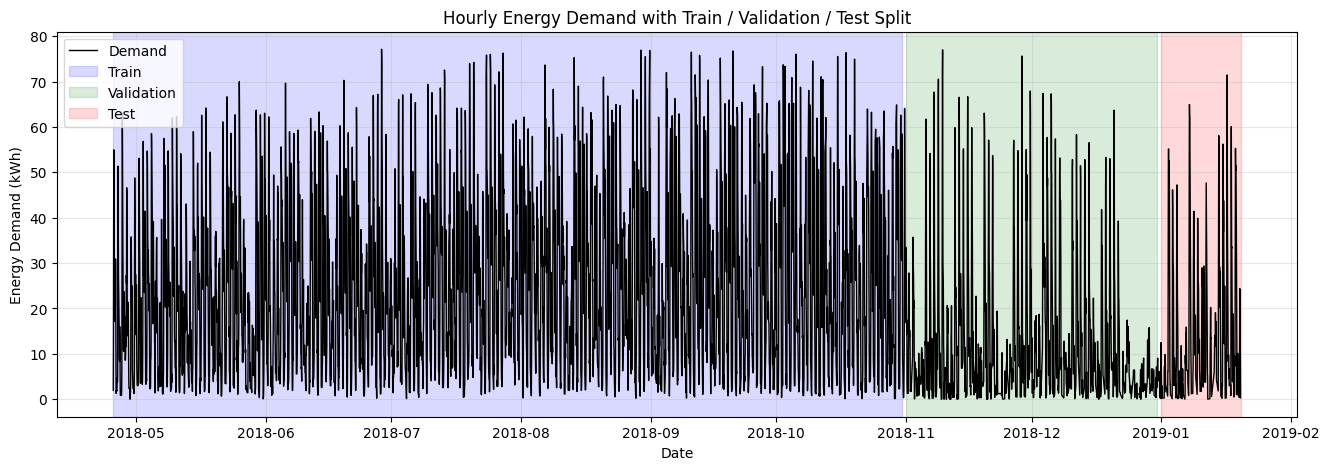

In [313]:
plt.figure(figsize=(16,5))

# Plot full demand curve
plt.plot(hourly_subset.index, hourly_subset['kWh'], color='black', linewidth=1, label='Demand')

# Shade regions
plt.axvspan(train_df.index.min(), train_df.index.max(),
            color='blue', alpha=0.15, label='Train')

plt.axvspan(val_df.index.min(), val_df.index.max(),
            color='green', alpha=0.15, label='Validation')

plt.axvspan(test_df.index.min(), test_df.index.max(),
            color='red', alpha=0.15, label='Test')

plt.title("Hourly Energy Demand with Train / Validation / Test Split")
plt.xlabel("Date")
plt.ylabel("Energy Demand (kWh)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

Plot to verify scaling: Powert​=fleet_size×ev_profilet​, Powert​=Fleet×EV_Energy×Profilet​

In [336]:
profile = hourly_subset['kWh']

normalized_profile = profile / profile.sum()

In [337]:
ev_annual_energy = 5600

In [338]:
ev_hourly_profile = normalized_profile * ev_annual_energy

In [339]:
fleet_size = 1000

fleet_profile = ev_hourly_profile * fleet_size

In [340]:
print("Energy per EV:", ev_hourly_profile.sum())
print("Energy fleet:", fleet_profile.sum())

Energy per EV: 5600.0
Energy fleet: 5600000.0


In [341]:
Power_profile = fleet_size * ev_hourly_profile

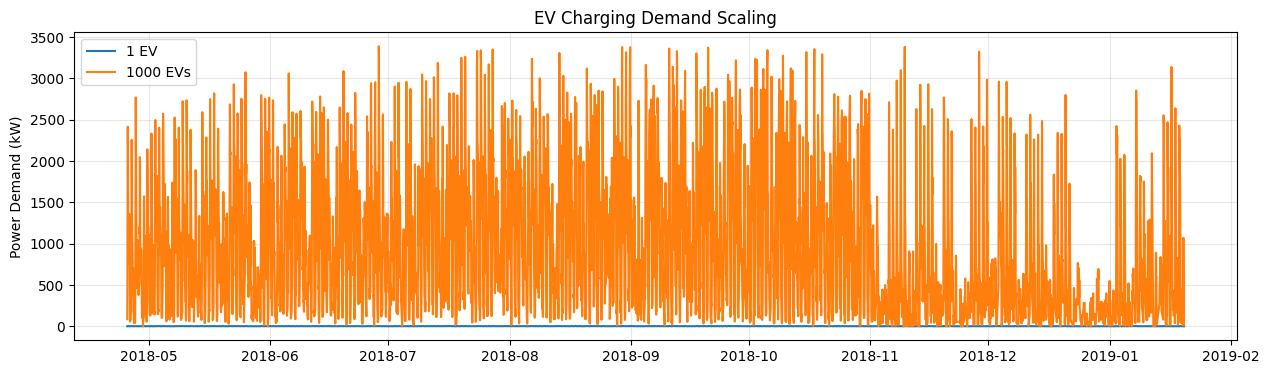

In [342]:
plt.figure(figsize=(15,4))

plt.plot(ev_hourly_profile.index, ev_hourly_profile,
         label="1 EV")

plt.plot(fleet_profile.index, fleet_profile,
         label=f"{fleet_size} EVs")

plt.legend()
plt.ylabel("Power Demand (kW)")
plt.title("EV Charging Demand Scaling")
plt.grid(alpha=0.3)
plt.show()